<a href="https://colab.research.google.com/github/ssykes-eth/ETH_275-0005-00L/blob/code_exercises/03_scoutai_workshop_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Building ScoutAI — from a plain chatbot to a real agent

> **The scenario.** You are on the strategy team at **Meridian Capital**. Every Monday your CEO wants a one-page competitive brief on a public company. Your junior analyst spends two days on each one. You have been told "just use ChatGPT". You will discover, in this notebook, why that answer only takes you 10% of the way — and what the other 90% looks like.

You will build the same competitor-brief tool **eight times**, adding one lecture concept per part. Every part ends with a quick 🧠 check to make sure the idea landed.


In [1]:
#@title 🔧 PROVIDED — Roadmap (run, don't edit) { display-mode: "form" }
from IPython.display import HTML, display
_steps = [
  ("💬", "1 · Plain LLM",     "chat completion",      "ask the model — hit the wall"),
  ("🛠️", "2 · Tools + LangChain", "@tool + ReAct",   "let the LLM call real APIs"),
  ("📚", "3 · RAG",            "your private docs",   "search internal memos alongside the web"),
  ("📐", "4 · Skills",         "reusable playbooks",  "consistent, auditable output"),
  ("🧠", "5 · Memory",         "cross-session facts", "remember house rules"),
  ("🕸️", "6 · LangGraph",      "orchestrator+workers","real control flow, parallel sub-agents"),
  ("🔌", "7 · MCP",            "tools as a protocol", "publish a schema, any agent can call it"),
  ("🤝", "8 · A2A",            "agent-to-agent",      "your agent hands work to another agent"),
]
_grad = ["#667eea","#7261d8","#7d5fd0","#895ec8","#9a63d4","#a961c8","#b95fbc","#c05fb0"]
_b = ""
for (_ic,_t,_q,_d),_g in zip(_steps,_grad):
    _b += (f'<div class="rm-step"><div class="rm-ic" style="background:linear-gradient(135deg,{_g},{_g}cc)">{_ic}</div>'
           f'<div class="rm-t">{_t}</div><div class="rm-q">{_q}</div><div class="rm-d">{_d}</div></div>')
display(HTML(f"""
<style>
.rm{{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border-radius:18px;padding:20px 16px;margin:8px 0;border:1px solid #ecebff}}
.rm-h{{font-size:20px;font-weight:800;color:#3b2d6b;margin:0 0 12px}}
.rm-row{{display:flex;flex-wrap:wrap;gap:6px}}
.rm-step{{flex:1 1 150px;min-width:140px;text-align:center;padding:8px 6px;background:#fff;border-radius:11px;border:1px solid #eee7f9}}
.rm-ic{{width:46px;height:46px;border-radius:50%;margin:0 auto 6px;display:flex;align-items:center;justify-content:center;font-size:22px;color:#fff;box-shadow:0 4px 10px rgba(102,126,234,.35)}}
.rm-t{{font-weight:800;font-size:12.5px;color:#2c2350}}
.rm-q{{font-size:10.5px;color:#8b5cf6;margin-top:3px;font-weight:700;font-family:ui-monospace,Menlo,monospace}}
.rm-d{{font-size:10.5px;color:#8b86a6;margin-top:5px;line-height:1.35}}
</style>
<div class="rm"><div class="rm-h">🗺️ Eight builds of the same tool. Each one fixes what the last could not do.</div>
<div class="rm-row">{_b}</div></div>"""))


---
## Part 0 · Setup

You need **one API key** and a minute of installs. Everything else in this notebook uses **free APIs that do not need a key** — Yahoo Finance for prices, Wikipedia for company summaries, Google News RSS for headlines.

**Get your LLM key** (pick one):

- **OpenRouter (recommended)** — sign in with Google at https://openrouter.ai/keys, create a key, it starts with `sk-or-`. Free tier is generous and gives you a menu of models (Claude, GPT, Gemini, Llama) behind one endpoint.
- **Gemini** — sign in at https://aistudio.google.com/apikey, create a key. Free tier available.

Paste the one you have. The next cell picks up whichever key you set.

> **Naming heads-up.** Two helpers you'll see everywhere below:
> - **`llm`** = our chat model (a `ChatOpenAI` instance). This is what every `create_agent(llm, ...)` call is given — it's what the agents talk to.
> - **`call_llm(prompt, system=None)`** and **`call_llm_json(prompt, system=None)`** = plain one-shot wrappers for when we want a direct answer from the model *without* wrapping it in an agent (e.g. inside a LangGraph node that just composes text).


In [2]:
%pip install -q openai google-generativeai langchain langchain-community langgraph langchain-openai chromadb sentence-transformers yfinance wikipedia feedparser


In [3]:
#@title 🔧 PROVIDED — LLM wrapper — works with OpenRouter OR Gemini (run, don't edit) { display-mode: "form" }
import os, json, re, getpass, requests, warnings
warnings.filterwarnings("ignore")   # silence noisy library warnings for a clean classroom output

# --- key: try both providers ------------------------------------------------
if not (os.environ.get("OPENROUTER_API_KEY") or os.environ.get("GEMINI_API_KEY")):
    try:
        from google.colab import userdata
        for k in ("OPENROUTER_API_KEY", "GEMINI_API_KEY"):
            try:
                v = userdata.get(k)
                if v: os.environ[k] = v
            except Exception:
                pass
    except Exception:
        pass
if not (os.environ.get("OPENROUTER_API_KEY") or os.environ.get("GEMINI_API_KEY")):
    key = getpass.getpass("Paste your API key (OpenRouter sk-or-... or Gemini AI... key): ").strip()
    if key.startswith("sk-or"):
        os.environ["OPENROUTER_API_KEY"] = key
    else:
        os.environ["GEMINI_API_KEY"] = key

PROVIDER = "openrouter" if os.environ.get("OPENROUTER_API_KEY") else "gemini"

# --- unified call_llm() and call_llm_json() one-shot wrappers ---------------
if PROVIDER == "openrouter":
    BASE_URL = "https://openrouter.ai/api/v1"
    HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}",
               "Content-Type": "application/json"}
    # Ordered cheap -> capable. All four reliably call tools; the cheaper ones
    # keep API costs manageable while students iterate. Override MODEL below if needed.
    PREFERRED = ["openai/gpt-4.1-mini", "google/gemini-2.0-flash-001",
                 "meta-llama/llama-3.3-70b-instruct", "anthropic/claude-sonnet-4.5"]
    try:
        avail = {m["id"] for m in requests.get(f"{BASE_URL}/models", timeout=20).json()["data"]}
        MODEL = next((m for m in PREFERRED if m in avail), PREFERRED[0])
    except Exception:
        MODEL = PREFERRED[0]

    def call_llm(prompt, system=None, temperature=0.0, max_tokens=900):
        msgs = ([{"role":"system","content":system}] if system else []) + [{"role":"user","content":prompt}]
        r = requests.post(f"{BASE_URL}/chat/completions", headers=HEADERS,
                          json={"model":MODEL,"messages":msgs,
                                "temperature":temperature,"max_tokens":max_tokens}, timeout=120)
        r.raise_for_status()
        return r.json()["choices"][0]["message"]["content"].strip()
else:
    import google.generativeai as genai
    genai.configure(api_key=os.environ["GEMINI_API_KEY"])
    MODEL = "gemini-2.0-flash"
    _model = genai.GenerativeModel(MODEL)
    def call_llm(prompt, system=None, temperature=0.0, max_tokens=900):
        full = (system + "\n\n" if system else "") + prompt
        r = _model.generate_content(full,
              generation_config={"temperature":temperature,"max_output_tokens":max_tokens})
        return r.text.strip()

def call_llm_json(prompt, system=None, **kw):
    """Same, but insists on JSON out."""
    sys = (system or "") + "\nReply with ONE JSON object. No prose, no code fences."
    raw = call_llm(prompt, system=sys.strip(), **kw)
    raw = re.sub(r"^```(?:json)?|```$", "", raw.strip(), flags=re.M).strip()
    try:    return json.loads(raw)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", raw, re.S)
        return json.loads(m.group(0)) if m else {}

print(f"✅ one-shot helpers ready · provider = {PROVIDER} · model = {MODEL}")
print("   → use call_llm(prompt) or call_llm_json(prompt) for direct generations without an agent.")


✅ one-shot helpers ready · provider = openrouter · model = openai/gpt-4.1-mini
   → use call_llm(prompt) or call_llm_json(prompt) for direct generations without an agent.


**The three companies we will investigate.** Real, public, well-known — so every tool call returns real data.


In [4]:
#@title 🔧 PROVIDED — Our three test companies (run, don't edit) { display-mode: "form" }
from IPython.display import HTML, display
COMPANIES = [
    {"name": "NVIDIA",   "ticker": "NVDA", "why": "AI chip incumbent"},
    {"name": "Palantir", "ticker": "PLTR", "why": "controversial data/AI vendor"},
    {"name": "Snowflake","ticker": "SNOW", "why": "cloud data warehouse in an AI pivot"},
]
_cards = ""
for c in COMPANIES:
    _cards += (f'<div class="co-c"><div class="co-t">{c["ticker"]}</div>'
               f'<div class="co-n">{c["name"]}</div><div class="co-w">{c["why"]}</div></div>')
display(HTML(f"""
<style>
.co{{font-family:system-ui;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:14px 16px;max-width:820px}}
.co-r{{display:flex;gap:10px;flex-wrap:wrap}}
.co-c{{flex:1 1 200px;background:#fff;border:1px solid #e7e4f6;border-radius:10px;padding:10px 12px}}
.co-t{{font-family:ui-monospace,Menlo;font-weight:800;color:#8b5cf6;font-size:12px}}
.co-n{{font-weight:800;color:#2c2350;font-size:14px;margin:2px 0}}
.co-w{{font-size:11.5px;color:#6b6685}}
</style>
<div class="co"><b style="color:#3b2d6b">🏢 The three companies we will investigate</b>
<div style="font-size:11.5px;color:#6b6685;margin:4px 0 10px">Real tickers. Real Yahoo Finance. Real Wikipedia. Real Google News.</div>
<div class="co-r">{_cards}</div></div>"""))


---
# Part 1 · The plain chatbot approach (and where it breaks)

The obvious first attempt: **just ask the LLM directly**. No tools, no retrieval, no orchestration. This is what "we already use ChatGPT" means at most firms today.

We will do this properly — call the model, get a brief, look at the output honestly — and then name every problem with it. Those problems are what motivate every subsequent part of the notebook.


### 🎯 1.1 — Ask the LLM for a competitive brief

Fill in the prompt. Ask for a one-page brief on **NVIDIA**. Include: recent news, current stock price, key risks, and 3 competitors.


In [5]:
# 🎯 TODO: write a prompt asking for a one-page competitive brief on NVIDIA.
#   Ask for: recent news, current stock price, key risks, 3 competitors.
prompt = "Give me a one-page brief on NVIDIA. Include: recent news, current stock price, key risks, and 3 competitors."   # 🎯 fill in

brief = call_llm(prompt)
print(brief[:2000])


**NVIDIA Corporation: One-Page Brief**

**Overview:**  
NVIDIA Corporation (NASDAQ: NVDA) is a leading American technology company specializing in graphics processing units (GPUs), artificial intelligence (AI), and high-performance computing. Founded in 1993, NVIDIA has become a dominant player in the gaming, data center, automotive, and professional visualization markets. Its GPUs are widely used for gaming, AI research, and data center acceleration.

**Recent News (as of June 2024):**  
- NVIDIA recently announced the launch of its next-generation GPU architecture, which promises significant improvements in AI processing power and energy efficiency. This new architecture is expected to bolster NVIDIA’s leadership in AI and data center markets.  
- The company reported strong Q1 2024 earnings, beating analyst expectations with robust revenue growth driven by demand in AI chips and data center products.  
- NVIDIA continues to expand its AI ecosystem through partnerships with major clo

### The wall — read your output critically

Look at what came back. Now compare it against what a *real* competitive brief needs. Five things almost certainly went wrong:

1. **Stock price is stale or refused.** The LLM's training data ends months ago; it either invents a price or says "I don't have realtime data". Either is unusable.
2. **News dates are made up.** The model produces plausible-sounding headlines with plausible-sounding dates. Some are real. Some are hallucinated. You cannot tell which.
3. **No sources.** Every claim floats. You cannot verify, cite, or audit any of it.
4. **Format drifts every run.** Run it three times, get three different structures. Impossible to productize into a workflow.
5. **No access to your firm's private context.** Anything your team knows internally is invisible to it.

**This is the ceiling of a plain chatbot.** Every part that follows fixes exactly one of these.


In [6]:
#@title 🔧 PROVIDED — Visualise the five gaps (run, don't edit) { display-mode: "form" }
from IPython.display import HTML, display
_gaps = [
  ("🕰️","Stale data",     "trained months ago, no live prices or filings",   "Part 2 · tools"),
  ("👻","Hallucinations", "invents news items that look real",                "Part 2 · tools"),
  ("🔗","No sources",     "every claim floats, nothing citable",              "Part 2 · tools + Part 3 · RAG"),
  ("🎲","Drifting format","different structure every run",                    "Part 4 · skills"),
  ("🔒","No private context","your internal memos are invisible to it",       "Part 3 · RAG"),
]
_rows = ""
for i,(ic,t,d,f) in enumerate(_gaps):
    _rows += (f'<div class="gp-r"><div class="gp-ic">{ic}</div>'
              f'<div class="gp-t"><div class="gp-h">{t}</div><div class="gp-d">{d}</div></div>'
              f'<div class="gp-f">→ fixed in <b>{f}</b></div></div>')
display(HTML(f"""
<style>
.gp{{font-family:system-ui;background:linear-gradient(135deg,#fbecea,#fbf5ff);border:1px solid #f1dcd9;border-radius:14px;padding:14px 16px;max-width:820px}}
.gp-r{{display:flex;align-items:center;gap:12px;background:#fff;border:1px solid #f1e0dc;border-radius:10px;padding:9px 12px;margin:6px 0}}
.gp-ic{{font-size:22px;width:36px;text-align:center}}
.gp-t{{flex:1}}
.gp-h{{font-weight:800;color:#2c2350;font-size:13px}}
.gp-d{{font-size:11px;color:#6b6685}}
.gp-f{{font-size:11px;color:#8b5cf6;font-weight:700}}
</style>
<div class="gp"><b style="color:#8b2c1e">🧱 The five gaps we have to close</b>
<div style="font-size:11.5px;color:#6b6685;margin:4px 0 6px">Every one of these is closed by exactly one part of the notebook.</div>
{_rows}</div>"""))


In [7]:
#@title 🧠 Quick check { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r"""
<style>
.qz-q1{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:16px 18px;max-width:820px;margin:8px 0;color:#2c2350}
.qz-q1 .qz-h{font-size:14px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.qz-q1 .qz-opt{display:block;width:100%;text-align:left;background:#fff;border:1px solid #e7e4f6;border-radius:9px;padding:9px 12px;margin:5px 0;font-size:12.5px;color:#2c2350;cursor:pointer;transition:.15s;font-family:inherit}
.qz-q1 .qz-opt:hover{border-color:#8b5cf6;background:#faf7ff}
.qz-q1 .qz-opt.ok{background:#e8f7ee;border-color:#39b36a;color:#1f6b3d}
.qz-q1 .qz-opt.no{background:#fbecea;border-color:#e0796d;color:#8b2c1e}
.qz-q1 .qz-fb{margin-top:10px;padding:10px 12px;border-radius:9px;font-size:12px;color:#4b3f7a;background:#f2f0fc;border-left:3px solid #667eea;display:none;line-height:1.55}
.qz-q1 .qz-fb.show{display:block}
</style>
<div class="qz-q1">
 <div class="qz-h">🧠 Why is the plain-LLM approach fundamentally unsuitable for productising a competitor-brief workflow?</div>
 <button class="qz-opt" data-i="0" onclick="qzPick_q1(0)">A. Because LLMs are too slow.</button><button class="qz-opt" data-i="1" onclick="qzPick_q1(1)">B. Because it cannot fetch live data, cite sources, or produce consistent output.</button><button class="qz-opt" data-i="2" onclick="qzPick_q1(2)">C. Because the LLM refuses to write about companies.</button><button class="qz-opt" data-i="3" onclick="qzPick_q1(3)">D. Because LangChain has not been installed yet.</button>
 <div class="qz-fb" id="qzFb_q1"></div>
</div>
<script>
function qzPick_q1(i){
  const correct = 1;
  const explain = "The three killers are: no live data (Part 2 fixes), no citations (Parts 2\u20133 fix), no consistency (Part 4 fixes). Slowness and refusals are not the issue.";
  document.querySelectorAll('.qz-q1 .qz-opt').forEach((b,j)=>{
    b.classList.remove('ok','no');
    if(j===correct) b.classList.add('ok');
    else if(j===i) b.classList.add('no');
  });
  const fb = document.getElementById('qzFb_q1');
  fb.classList.add('show');
  fb.innerHTML = (i===correct ? '✅ Correct. ' : '❌ Not quite. ') + explain;
}
</script>
"""))


---
# Part 2 · Tools + LangChain — the bare agent

A **tool** is a plain Python function the LLM is allowed to call. The `@tool` decorator turns the docstring + type hints into a schema the model reads. The docstring becomes the **tool description** that gets injected into the model's prompt, so the model can decide **whether and which** tool to call.

We now give the model five real tools that hit **real APIs** — no keys needed:

- `get_stock_snapshot` → Yahoo Finance (via `yfinance`)
- `get_company_summary` → Wikipedia (via `wikipedia` package)
- `get_news` → Google News RSS (via `feedparser`)
- `get_recent_filings` → SEC EDGAR (public JSON endpoint)
- `save_brief` → write to disk in Colab

Then we wrap the tools with LangChain's ReAct agent and watch the loop: **plan → tool call → observation → plan → tool call → final answer**.


In [8]:
#@title 🔧 PROVIDED — Five real tools — hit real APIs, no keys (run, don't edit) { display-mode: "form" }
import yfinance as yf
import feedparser, requests, os
from urllib.parse import quote
from langchain_core.tools import tool

_WIKI_HEADERS = {"User-Agent": "ScoutAI-workshop/1.0 (classroom exercise)"}

@tool
def get_stock_snapshot(ticker: str) -> dict:
    """Fetch current price, 5-day % change, and market cap for a public equity ticker (e.g. 'NVDA')."""
    t = yf.Ticker(ticker)
    hist = t.history(period="5d")
    if hist.empty: return {"error": f"no data for {ticker}"}
    price = float(hist["Close"].iloc[-1])
    chg = float((hist["Close"].iloc[-1]/hist["Close"].iloc[0]-1)*100)
    info = t.info if hasattr(t, "info") else {}
    return {"ticker": ticker, "price_usd": round(price,2),
            "change_5d_pct": round(chg,2),
            "market_cap_usd": info.get("marketCap")}

def _wiki_summary(title: str) -> str | None:
    """Hit Wikipedia's REST summary endpoint. Returns None on 404 / HTML / disambig."""
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{quote(title)}"
    try:
        r = requests.get(url, headers=_WIKI_HEADERS, timeout=15)
    except Exception:
        return None
    if r.status_code != 200 or not r.headers.get("content-type","").startswith("application/json"):
        return None
    try:
        j = r.json()
    except Exception:
        return None
    if j.get("type") == "disambiguation":
        return None
    extract = j.get("extract") or ""
    # keep it short (~3 sentences)
    return ". ".join(extract.split(". ")[:3]).strip() or None

def _wiki_search_first(query: str) -> str | None:
    """Fall back to the OpenSearch endpoint to find a real title, then summarise it."""
    url = f"https://en.wikipedia.org/w/api.php?action=opensearch&format=json&limit=1&search={quote(query)}"
    try:
        r = requests.get(url, headers=_WIKI_HEADERS, timeout=15)
        titles = r.json()[1]
    except Exception:
        return None
    if not titles: return None
    return _wiki_summary(titles[0])

@tool
def get_company_summary(company: str) -> str:
    """Return a 2-3 sentence summary of a company from Wikipedia. Robust to
    disambiguation pages and missing titles: falls back to Wikipedia's search API."""
    # 1) direct summary
    s = _wiki_summary(company)
    if s: return s
    # 2) try appending " (company)" — common disambiguation suffix
    s = _wiki_summary(f"{company} (company)")
    if s: return s
    # 3) fall back to search
    s = _wiki_search_first(company)
    if s: return s
    return f"no wikipedia summary found for '{company}'"

@tool
def get_news(company: str, max_items: int = 5) -> list:
    """Fetch recent news headlines about a company from Google News RSS. Returns [{title, date, link}]."""
    q = company.replace(" ", "+")
    feed = feedparser.parse(f"https://news.google.com/rss/search?q={q}&hl=en-US&gl=US&ceid=US:en")
    return [{"title": e.title, "date": e.get("published","?"), "link": e.link}
            for e in feed.entries[:max_items]]

@tool
def get_recent_filings(ticker: str, max_items: int = 3) -> list:
    """Return recent SEC filings (10-K, 10-Q, 8-K) for a US ticker via SEC EDGAR."""
    try:
        m = requests.get("https://www.sec.gov/files/company_tickers.json",
                         headers={"User-Agent":"ScoutAI workshop meridian@example.com"}, timeout=15).json()
        cik = next((f"{v['cik_str']:010d}" for v in m.values() if v["ticker"]==ticker.upper()), None)
        if not cik: return [{"error": f"no CIK for {ticker}"}]
        j = requests.get(f"https://data.sec.gov/submissions/CIK{cik}.json",
                         headers={"User-Agent":"ScoutAI workshop meridian@example.com"}, timeout=15).json()
        rec = j["filings"]["recent"]
        return [{"form": rec["form"][i], "filed": rec["filingDate"][i], "accession": rec["accessionNumber"][i]}
                for i in range(min(max_items, len(rec["form"])))]
    except Exception as e:
        return [{"error": str(e)}]

@tool
def save_brief(company: str, brief_markdown: str) -> str:
    """Save a completed brief as a markdown file. Returns the file path."""
    os.makedirs("/content/briefs", exist_ok=True) if os.path.exists("/content") else os.makedirs("briefs", exist_ok=True)
    d = "/content/briefs" if os.path.exists("/content") else "briefs"
    p = f"{d}/{company.replace(' ','_')}_brief.md"
    with open(p,"w") as f: f.write(brief_markdown)
    return f"saved to {p}"

TOOLS_BASE = [get_stock_snapshot, get_company_summary, get_news, get_recent_filings, save_brief]
print(f"✅ Registered {len(TOOLS_BASE)} real tools.")
# quick sanity
print("Live price NVDA:", get_stock_snapshot.invoke({"ticker":"NVDA"}))
print("Wiki NVIDIA:", get_company_summary.invoke({"company":"NVIDIA"})[:120], "…")


✅ Registered 5 real tools.
Live price NVDA: {'ticker': 'NVDA', 'price_usd': 216.85, 'change_5d_pct': -3.69, 'market_cap_usd': 5252323999744}
Wiki NVIDIA: Nvidia Corporation is an American multinational technology company headquartered in Santa Clara, California. The company …


### 🎯 2.1 — Wire the agent

`create_agent(llm, tools)` gives you a working ReAct loop in one line. It needs an LLM that speaks the OpenAI/tool-calling protocol — we wire one to whichever provider you configured.

Fill in the blank below: call `create_agent` on the chat model and our five base tools.


In [9]:
#@title 🔧 PROVIDED — Bind the LLM in a tool-calling format (run, don't edit) { display-mode: "form" }
# Both OpenRouter and Gemini are reachable via an OpenAI-compatible endpoint.
from langchain_openai import ChatOpenAI
if PROVIDER == "openrouter":
    llm = ChatOpenAI(model=MODEL, base_url="https://openrouter.ai/api/v1",
                       api_key=os.environ["OPENROUTER_API_KEY"], temperature=0)
else:
    llm = ChatOpenAI(model=MODEL, base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
                       api_key=os.environ["GEMINI_API_KEY"], temperature=0)
print("✅ `llm` (ChatOpenAI, tool-calling) ready · model =", MODEL)


✅ `llm` (ChatOpenAI, tool-calling) ready · model = openai/gpt-4.1-mini


In [10]:
from langchain.agents import create_agent

# 🎯 TODO: create a ReAct agent with the chat model and our 5 base tools.
#         Hint: create_agent takes (llm, tools). Assign the result to agent_v1.
agent_v1 = create_agent(llm, TOOLS_BASE)   # 🎯

# Run it on NVIDIA
result = agent_v1.invoke({"messages": [("user",
    "Write a one-page competitive brief on NVIDIA. Include live price, 3 recent news items, and their most recent SEC filing.")]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Write a one-page competitive brief on NVIDIA. Include live price, 3 recent news items, and their most recent SEC filing.
================================== Ai Message ==================================
Tool Calls:
  get_stock_snapshot (call_oOCk4Zj9us8aym3PGO5SKQwp)
 Call ID: call_oOCk4Zj9us8aym3PGO5SKQwp
  Args:
    ticker: NVDA
  get_news (call_vPxzIhD893SrQ4zHyUETee0e)
 Call ID: call_vPxzIhD893SrQ4zHyUETee0e
  Args:
    company: NVIDIA
    max_items: 3
  get_recent_filings (call_OUrUpCfLCXh4QOphJbKdWKvy)
 Call ID: call_OUrUpCfLCXh4QOphJbKdWKvy
  Args:
    ticker: NVDA
    max_items: 1
  get_company_summary (call_Cd1dkJA9u482Iuut1KdzqyJr)
 Call ID: call_Cd1dkJA9u482Iuut1KdzqyJr
  Args:
    company: NVIDIA
================================= Tool Message =================================
Name: get_stock_snapshot

{"ticker": "NVDA", "price_usd": 216.85, "change_5d_pct": -3.69, "market_cap_usd": 525232399974

Look at the trace above. You will see the model **choose** which tool to call, get back a result, and use it. Compare with Part 1: the price is real now. The news is real now. The filing is real now.


In [11]:
#@title 🔧 PROVIDED — Visualise the agent's trace (run, don't edit) { display-mode: "form" }
from IPython.display import HTML, display
_events = []
for m in result["messages"]:
    typ = type(m).__name__
    if typ == "HumanMessage":
        _events.append(("👤","User", m.content[:200], "#667eea"))
    elif typ == "AIMessage" and getattr(m,"tool_calls",None):
        for tc in m.tool_calls:
            _events.append(("🧠","Agent → tool call", f"{tc['name']}({tc['args']})", "#8b5cf6"))
    elif typ == "ToolMessage":
        _events.append(("🛠️","Tool → observation", str(m.content)[:220], "#39b36a"))
    elif typ == "AIMessage":
        _events.append(("✅","Agent → final answer", (m.content or "")[:400], "#e0a23c"))
_rows = ""
for ic,t,d,c in _events:
    _rows += (f'<div class="tr-r" style="border-left:3px solid {c}">'
              f'<div class="tr-h">{ic} {t}</div><div class="tr-d">{d}</div></div>')
display(HTML(f"""
<style>
.tr{{font-family:system-ui;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border-radius:14px;padding:14px;max-width:900px}}
.tr-r{{background:#fff;border:1px solid #ecebff;border-radius:9px;padding:8px 12px;margin:5px 0}}
.tr-h{{font-weight:800;color:#2c2350;font-size:12px}}
.tr-d{{font-size:11px;color:#4b3f7a;font-family:ui-monospace,Menlo;white-space:pre-wrap;margin-top:3px}}
</style>
<div class="tr"><b style="color:#3b2d6b">📊 The ReAct loop, decoded</b>
<div style="font-size:11.5px;color:#6b6685;margin:4px 0 6px">Each row is one message in the loop. Notice how tool calls (🧠) alternate with observations (🛠️) until the model has enough to answer (✅).</div>
{_rows}</div>"""))


In [12]:
#@title 🧠 Quick check { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r"""
<style>
.qz-q2{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:16px 18px;max-width:820px;margin:8px 0;color:#2c2350}
.qz-q2 .qz-h{font-size:14px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.qz-q2 .qz-opt{display:block;width:100%;text-align:left;background:#fff;border:1px solid #e7e4f6;border-radius:9px;padding:9px 12px;margin:5px 0;font-size:12.5px;color:#2c2350;cursor:pointer;transition:.15s;font-family:inherit}
.qz-q2 .qz-opt:hover{border-color:#8b5cf6;background:#faf7ff}
.qz-q2 .qz-opt.ok{background:#e8f7ee;border-color:#39b36a;color:#1f6b3d}
.qz-q2 .qz-opt.no{background:#fbecea;border-color:#e0796d;color:#8b2c1e}
.qz-q2 .qz-fb{margin-top:10px;padding:10px 12px;border-radius:9px;font-size:12px;color:#4b3f7a;background:#f2f0fc;border-left:3px solid #667eea;display:none;line-height:1.55}
.qz-q2 .qz-fb.show{display:block}
</style>
<div class="qz-q2">
 <div class="qz-h">🧠 The docstring on a @tool function is important because…</div>
 <button class="qz-opt" data-i="0" onclick="qzPick_q2(0)">A. It is required Python syntax; the tool will not compile without it.</button><button class="qz-opt" data-i="1" onclick="qzPick_q2(1)">B. The LLM reads it to decide when to call the tool — bad docstring, wrong tool at the wrong time.</button><button class="qz-opt" data-i="2" onclick="qzPick_q2(2)">C. It gets logged to the console for debugging.</button><button class="qz-opt" data-i="3" onclick="qzPick_q2(3)">D. It controls the tool's return type.</button>
 <div class="qz-fb" id="qzFb_q2"></div>
</div>
<script>
function qzPick_q2(i){
  const correct = 1;
  const explain = "The description IS the prompt. 80% of building an agent is writing sharp tool descriptions so the model knows when to reach for which tool.";
  document.querySelectorAll('.qz-q2 .qz-opt').forEach((b,j)=>{
    b.classList.remove('ok','no');
    if(j===correct) b.classList.add('ok');
    else if(j===i) b.classList.add('no');
  });
  const fb = document.getElementById('qzFb_q2');
  fb.classList.add('show');
  fb.innerHTML = (i===correct ? '✅ Correct. ' : '❌ Not quite. ') + explain;
}
</script>
"""))


---
# Part 3 · RAG — bring in your firm's private knowledge

Public APIs cover what everyone knows. The reason your team is paid is because they know things **the internet does not** — old research memos, meeting notes, private conversations with management. RAG (Retrieval-Augmented Generation) is how we make that private context available to the agent.

The recipe: **chunk → embed → store**, then at query time **embed the question → find the closest chunks → paste them into the prompt**.

We fake five internal memos and put them in an in-memory Chroma store. Then we expose one new tool: `search_our_research`.


In [13]:
#@title 🔧 PROVIDED — Five fake internal Meridian Capital memos (run, don't edit) { display-mode: "form" }
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document

MEMOS = [
    Document(page_content="Internal · Jun 2026 · NVIDIA: our channel checks with three hyperscaler CTOs suggest H200 demand is being cannibalised by their internal ASIC roadmaps. Not visible in reported revenue yet.", metadata={"src":"memo-2026-06-nvda"}),
    Document(page_content="Internal · May 2026 · Palantir: two ex-Foundry engineers we spoke to say the AIP platform's margins are lower than reported because of heavy solutions-engineering support per deal.", metadata={"src":"memo-2026-05-pltr"}),
    Document(page_content="Internal · Jul 2026 · Snowflake: our contact at a Fortune-100 healthcare customer confirmed they are running a full Databricks bake-off in H2. Likely a rip-and-replace decision by Q4.", metadata={"src":"memo-2026-07-snow"}),
    Document(page_content="House rule · The CFO wants every brief to lead with Risk Factors, not with an executive summary.", metadata={"src":"house-rules"}),
    Document(page_content="House rule · Never quote a number from an unpublished channel check without the phrase 'per our channel checks'. Compliance requirement.", metadata={"src":"house-rules"}),
]

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vstore = Chroma.from_documents(MEMOS, embeddings)
print(f"✅ {len(MEMOS)} memos embedded into vector store")


/tmp/ipykernel_2678/2807271803.py:14: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ 5 memos embedded into vector store


### 🎯 3.1 — Write the retrieval tool

Fill in the tool that queries the vector store. The docstring becomes the tool description the LLM reads to decide when to call this tool — make it clear when the agent should reach for internal research vs. the public web.


In [14]:
@tool
def search_our_research(query: str) -> list:
    """Search Meridian Capital's private research memos, house rules, and channel
    checks. Use this whenever the user needs internal context that is NOT on the
    public web (e.g. our view on a company, our house style, our compliance rules)."""
    # 🎯 TODO — 2 lines of code:
    #   1. Call vstore.similarity_search(query, k=3) to get the top 3 matching memos.
    #   2. Return them as a list of dicts, one per memo, shaped like:
    #        {"src": doc.metadata["src"], "text": doc.page_content}
    #      (`doc` is what similarity_search returns — each doc has .metadata and .page_content.)
    hits = vstore.similarity_search(query, k=3)                                              # ┐ similarity_search
    return [{"src": doc.metadata["src"], "text": doc.page_content} for doc in hits ]                          # ┐ build the dict list

TOOLS_RAG = TOOLS_BASE + [search_our_research]
print(f"✅ Now have {len(TOOLS_RAG)} tools.")

✅ Now have 6 tools.


In [15]:
# Run the agent again — this time with the retrieval tool available.
# Print the full trace so you can see the agent choose search_our_research on its own.
agent_v2 = create_agent(llm, TOOLS_RAG)
result = agent_v2.invoke({"messages": [("user",
    "Brief me on NVIDIA. Cross-check public info with anything our internal team has written.")]})
for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

Brief me on NVIDIA. Cross-check public info with anything our internal team has written.
================================== Ai Message ==================================
Tool Calls:
  get_company_summary (call_aKmeGlFFOWDpcpOpwYWl1iFZ)
 Call ID: call_aKmeGlFFOWDpcpOpwYWl1iFZ
  Args:
    company: NVIDIA
  search_our_research (call_08mEa1uT45oKlEGk9Ag7NWRN)
 Call ID: call_08mEa1uT45oKlEGk9Ag7NWRN
  Args:
    query: NVIDIA
================================= Tool Message =================================
Name: get_company_summary

Nvidia Corporation is an American multinational technology company headquartered in Santa Clara, California. The company develops graphics processing units (GPUs), systems on chips (SoCs), and application programming interfaces (APIs) for data science, high-performance computing, artificial intelligence (AI), and mobile and automotive applications. Founded in 1993 by Jensen Huang, Ch

Notice: the agent chose to call `search_our_research` on its own — nobody told it to. That is the description-as-prompt working. And the brief now surfaces the channel-check point about H200 cannibalisation — a fact that exists only inside your firm.


In [16]:
#@title 🧠 Quick check { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r"""
<style>
.qz-q3{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:16px 18px;max-width:820px;margin:8px 0;color:#2c2350}
.qz-q3 .qz-h{font-size:14px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.qz-q3 .qz-opt{display:block;width:100%;text-align:left;background:#fff;border:1px solid #e7e4f6;border-radius:9px;padding:9px 12px;margin:5px 0;font-size:12.5px;color:#2c2350;cursor:pointer;transition:.15s;font-family:inherit}
.qz-q3 .qz-opt:hover{border-color:#8b5cf6;background:#faf7ff}
.qz-q3 .qz-opt.ok{background:#e8f7ee;border-color:#39b36a;color:#1f6b3d}
.qz-q3 .qz-opt.no{background:#fbecea;border-color:#e0796d;color:#8b2c1e}
.qz-q3 .qz-fb{margin-top:10px;padding:10px 12px;border-radius:9px;font-size:12px;color:#4b3f7a;background:#f2f0fc;border-left:3px solid #667eea;display:none;line-height:1.55}
.qz-q3 .qz-fb.show{display:block}
</style>
<div class="qz-q3">
 <div class="qz-h">🧠 In this notebook, how does the agent perform RAG?</div>
 <button class="qz-opt" data-i="0" onclick="qzPick_q3(0)">A. RAG runs automatically inside the LLM without any explicit code.</button><button class="qz-opt" data-i="1" onclick="qzPick_q3(1)">B. The retrieval function is exposed as a @tool — tools are the mechanism through which the LLM invokes retrieval; RAG is one use case of tools.</button><button class="qz-opt" data-i="2" onclick="qzPick_q3(2)">C. RAG replaces tools once a corpus exists.</button><button class="qz-opt" data-i="3" onclick="qzPick_q3(3)">D. You must call the vector store manually before every user message.</button>
 <div class="qz-fb" id="qzFb_q3"></div>
</div>
<script>
function qzPick_q3(i){
  const correct = 1;
  const explain = "Tools are the general mechanism the LLM uses to invoke any external action — including querying a vector store. RAG is one use case built on top of the tool interface, not a separate concept.";
  document.querySelectorAll('.qz-q3 .qz-opt').forEach((b,j)=>{
    b.classList.remove('ok','no');
    if(j===correct) b.classList.add('ok');
    else if(j===i) b.classList.add('no');
  });
  const fb = document.getElementById('qzFb_q3');
  fb.classList.add('show');
  fb.innerHTML = (i===correct ? '✅ Correct. ' : '❌ Not quite. ') + explain;
}
</script>
"""))


---
# Part 4 · Skills — reusable playbooks for consistent output

The briefs above are useful but they look *different* every run. Format drifts. Tone drifts. Some runs put risk first, some don't. That is a productization killer — you cannot build a downstream workflow on non-deterministic structure.

A **skill** is a bundle: a system prompt, a format template, an example, and the list of tools it is allowed to use. Anthropic, Cursor, and OpenAI all ship "Skills" as a first-class primitive in 2025. What is a skill in practice? Read the one below.


### 🎯 4.1 — Complete the skill

The format block is missing three sections. Fill them in with the structure your firm wants for every brief.


In [18]:
COMPETITIVE_BRIEF_SKILL = """You are ScoutAI, competitive-intelligence agent for Meridian Capital.

BEFORE YOU START:
- Call search_our_research('house rules') and follow anything you find there.

FORMAT — every brief you produce follows this structure exactly:

# {Company} — One-page brief

## Risk factors
- Briefly identify 2-3 key risks, starting with the most significant one. Each risk should be a bullet point.
- Provide a concise explanation for each risk.
- Always cite your source for the risk (e.g., SEC filing, news article).

## Strategy & recent signals
- Start with a short paragraph summarizing the company's overall strategy or recent strategic moves.
- Follow with 3 bullet points detailing recent news items or signals that support or relate to the strategy. Include a brief explanation of why each news item is significant.

## Our view
- Provide a single, concise line summarizing Meridian Capital's view on the company.
- If using internal data or channel checks, ensure to explicitly use the phrase 'per our channel checks' to hedge the statement.

RULES:
- Never invent numbers. If a field is missing, write 'not disclosed'.
- Always end with: 'Source: ScoutAI · not investment advice'.
"""

agent_skilled = create_agent(llm, TOOLS_RAG, system_prompt=COMPETITIVE_BRIEF_SKILL)
result = agent_skilled.invoke({"messages":[{"role": "user", "content":"Brief me on Palantir."}]})
print(result["messages"][-1].content)

# Palantir Technologies — One-page brief

## Risk factors
- Heavy reliance on government contracts: Palantir derives a significant portion of its revenue from government agencies, which can be subject to budget cuts, regulatory changes, or shifts in political priorities, potentially impacting revenue stability (company filings).
- Privacy and regulatory scrutiny: As a data integration and analytics company, Palantir faces risks related to data privacy laws and regulatory compliance, which could lead to legal challenges or restrictions on its operations (news articles).
- Market competition and technology risk: The company operates in a highly competitive tech sector with rapid innovation cycles, which requires continuous investment in R&D to maintain its competitive edge (company filings).

## Strategy & recent signals
Palantir focuses on providing advanced data integration and analytics software primarily to government and commercial clients, leveraging its technology to address compl

Run the same cell twice on two different companies. The output structure is now **identical** — same headings, same disclaimer. Auditability comes from consistency.


In [19]:
#@title 🧠 Quick check { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r"""
<style>
.qz-q4{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:16px 18px;max-width:820px;margin:8px 0;color:#2c2350}
.qz-q4 .qz-h{font-size:14px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.qz-q4 .qz-opt{display:block;width:100%;text-align:left;background:#fff;border:1px solid #e7e4f6;border-radius:9px;padding:9px 12px;margin:5px 0;font-size:12.5px;color:#2c2350;cursor:pointer;transition:.15s;font-family:inherit}
.qz-q4 .qz-opt:hover{border-color:#8b5cf6;background:#faf7ff}
.qz-q4 .qz-opt.ok{background:#e8f7ee;border-color:#39b36a;color:#1f6b3d}
.qz-q4 .qz-opt.no{background:#fbecea;border-color:#e0796d;color:#8b2c1e}
.qz-q4 .qz-fb{margin-top:10px;padding:10px 12px;border-radius:9px;font-size:12px;color:#4b3f7a;background:#f2f0fc;border-left:3px solid #667eea;display:none;line-height:1.55}
.qz-q4 .qz-fb.show{display:block}
</style>
<div class="qz-q4">
 <div class="qz-h">🧠 Why do 'Skills' matter for productisation?</div>
 <button class="qz-opt" data-i="0" onclick="qzPick_q4(0)">A. They make the model faster.</button><button class="qz-opt" data-i="1" onclick="qzPick_q4(1)">B. They give the same input a predictable, consistent output — auditable and reviewable.</button><button class="qz-opt" data-i="2" onclick="qzPick_q4(2)">C. They reduce the number of tokens the model uses.</button><button class="qz-opt" data-i="3" onclick="qzPick_q4(3)">D. They replace the need for tools.</button>
 <div class="qz-fb" id="qzFb_q4"></div>
</div>
<script>
function qzPick_q4(i){
  const correct = 1;
  const explain = "Consistency = auditability. Without a skill, the same prompt gives different-shaped output every run. With a skill, the format is locked and downstream workflows can rely on it.";
  document.querySelectorAll('.qz-q4 .qz-opt').forEach((b,j)=>{
    b.classList.remove('ok','no');
    if(j===correct) b.classList.add('ok');
    else if(j===i) b.classList.add('no');
  });
  const fb = document.getElementById('qzFb_q4');
  fb.classList.add('show');
  fb.innerHTML = (i===correct ? '✅ Correct. ' : '❌ Not quite. ') + explain;
}
</script>
"""))


---
# Part 5 · Memory — what the agent remembers across sessions

**Short-term memory** = the conversation. Resets every run.
**Long-term memory** = a store *outside* the messages that survives.

We give the agent two tools:
- **`remember(topic, fact)`** — *writes* to the store. The agent calls it when the user teaches it something durable ("our CFO wants risk first", "never quote unpublished figures").
- **`recall(topic)`** — *reads* from the store. The agent calls it when it needs to check whether we already know something about a topic before answering.

Both are needed because the store the agent writes to is not automatically in its prompt — it has to *retrieve* it back with `recall` when relevant, exactly like RAG.


### 🎯 5.1 — Add remember/recall tools

Two small tools operating on the same dict. The descriptions are already written — you just fill in the one-liner that reads or writes to `LONG_TERM_MEMORY`.


In [20]:
LONG_TERM_MEMORY = {}   # in prod: Mem0 / LangMem / Zep / Redis+embeddings

@tool
def remember(topic: str, fact: str) -> str:
    """Store a durable fact under a topic. Use when the user teaches you a house
    rule, a preference, or a lesson that should apply to future briefs."""
    # 🎯 TODO — 1 line: append `fact` to the list under LONG_TERM_MEMORY[topic].
    #   Hint: use LONG_TERM_MEMORY.setdefault(topic, []).append(fact)
    LONG_TERM_MEMORY.setdefault(topic, []).append(fact)
    return f"remembered under '{topic}'"

@tool
def recall(topic: str) -> list:
    """Retrieve everything previously remembered under a topic. Use at the start
    of a task to check whether we already have house rules or context on this."""
    # 🎯 TODO — 1 line: return the list at LONG_TERM_MEMORY[topic] (empty list if missing).
    #   Hint: LONG_TERM_MEMORY.get(topic, [])
    return LONG_TERM_MEMORY.get(topic, [])

TOOLS_MEM = TOOLS_RAG + [remember, recall]

In [21]:
# Session 1: teach the agent a house rule. Note we do NOT say "store this" —
# the agent decides on its own to call `remember` because its description matches.
agent_mem = create_agent(llm, TOOLS_MEM, system_prompt=COMPETITIVE_BRIEF_SKILL)
r1 = agent_mem.invoke({"messages":[("user",
    "New house rule from the CFO: every brief must lead with the Risk Factors section from now on.")]})
print(r1["messages"][-1].content)
print("\n📦 Memory now contains:", LONG_TERM_MEMORY)


I have noted the new house rule from the CFO: every brief must lead with the Risk Factors section from now on. I will follow this rule in all future briefs. How can I assist you next?

📦 Memory now contains: {'house rules': ['Every brief must lead with the Risk Factors section from now on.']}


In [22]:
# Session 2: brand-new conversation. The messages from session 1 are gone.
# But the dict survived — and the agent's `recall` description tells it to check
# for house rules on its own, without us reminding it. That is long-term memory.
r2 = agent_mem.invoke({"messages":[("user",
    "Brief me on Snowflake.")]})
print(r2["messages"][-1].content)


# Snowflake — One-page brief

## Risk factors
- Competitive pressure: Snowflake operates in the highly competitive cloud data platform market, facing strong competition from major players like Amazon Web Services, Google Cloud, and Microsoft Azure, which could impact its market share and pricing power. (General industry knowledge)
- Dependence on cloud infrastructure providers: Snowflake relies on third-party cloud infrastructure providers to deliver its services, which exposes it to risks related to service disruptions, pricing changes, or technology shifts by these providers. (General industry knowledge)
- Regulatory and data privacy risks: As a data platform handling sensitive customer data, Snowflake faces risks from evolving data privacy regulations and compliance requirements globally, which could increase operational costs or limit service offerings. (General industry knowledge)

## Strategy & recent signals
Snowflake's strategy centers on providing a cloud-native data platform 

In [23]:
#@title 🧠 Quick check { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r"""
<style>
.qz-q5{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:16px 18px;max-width:820px;margin:8px 0;color:#2c2350}
.qz-q5 .qz-h{font-size:14px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.qz-q5 .qz-opt{display:block;width:100%;text-align:left;background:#fff;border:1px solid #e7e4f6;border-radius:9px;padding:9px 12px;margin:5px 0;font-size:12.5px;color:#2c2350;cursor:pointer;transition:.15s;font-family:inherit}
.qz-q5 .qz-opt:hover{border-color:#8b5cf6;background:#faf7ff}
.qz-q5 .qz-opt.ok{background:#e8f7ee;border-color:#39b36a;color:#1f6b3d}
.qz-q5 .qz-opt.no{background:#fbecea;border-color:#e0796d;color:#8b2c1e}
.qz-q5 .qz-fb{margin-top:10px;padding:10px 12px;border-radius:9px;font-size:12px;color:#4b3f7a;background:#f2f0fc;border-left:3px solid #667eea;display:none;line-height:1.55}
.qz-q5 .qz-fb.show{display:block}
</style>
<div class="qz-q5">
 <div class="qz-h">🧠 The 'session 2' conversation had none of the messages from session 1. So how did the CFO's rule survive?</div>
 <button class="qz-opt" data-i="0" onclick="qzPick_q5(0)">A. It didn't — the model guessed correctly.</button><button class="qz-opt" data-i="1" onclick="qzPick_q5(1)">B. The rule was stored in an external store (our dict). Short-term memory reset; long-term did not.</button><button class="qz-opt" data-i="2" onclick="qzPick_q5(2)">C. LangChain caches every conversation automatically.</button><button class="qz-opt" data-i="3" onclick="qzPick_q5(3)">D. The system prompt copied it.</button>
 <div class="qz-fb" id="qzFb_q5"></div>
</div>
<script>
function qzPick_q5(i){
  const correct = 1;
  const explain = "Short-term memory (messages) and long-term memory (external store) are separate. The messages reset every session. The dict \u2014 or a vector DB in production \u2014 persists.";
  document.querySelectorAll('.qz-q5 .qz-opt').forEach((b,j)=>{
    b.classList.remove('ok','no');
    if(j===correct) b.classList.add('ok');
    else if(j===i) b.classList.add('no');
  });
  const fb = document.getElementById('qzFb_q5');
  fb.classList.add('show');
  fb.innerHTML = (i===correct ? '✅ Correct. ' : '❌ Not quite. ') + explain;
}
</script>
"""))


---
# Part 6 · LangGraph — orchestrator dispatching to sub-agents

A single ReAct agent is fine for one loop of tool-calling, but real production agents have **branches, parallel workers, and control flow you can inspect**. That is LangGraph.

We are going to build the picture from the slide: a **router node** that dispatches work to three **sub-agents in parallel**, then merges their outputs, drafts a brief, and runs a self-critique pass.

**Key architectural point:** each sub-agent is its own ReAct agent with its own narrow toolset. The graph itself is the orchestration — no single node "does everything". This is the pattern Anthropic's Claude Code, Cursor's background agents, and OpenAI's Swarm all use.


In [24]:
# The three sub-agents that Part 6 orchestrates. Each is a full ReAct agent with its own tools and system prompt — read them before wiring the graph so you know what each specialist does.
from langchain.agents import create_agent
# Three specialists. Each is a full ReAct agent — with its own tools and system prompt.
financials_agent = create_agent(llm,
    tools=[get_stock_snapshot, get_recent_filings],
    system_prompt="You are a financials specialist. Given a company, return a 3-sentence summary of its current price, recent SEC filings, and any red flags. Be concise.")

news_agent = create_agent(llm,
    tools=[get_news, get_company_summary],
    system_prompt="You are a news specialist. Return the 3 most important recent news items about a company, one line each, with a one-sentence 'why it matters'.")

research_agent = create_agent(llm,
    tools=[search_our_research],
    system_prompt="You are our internal research specialist. Search Meridian's private memos and return any relevant channel checks or house rules for the given company. Cite the memo id.")

print("✅ 3 sub-agents created, each with its own toolset.")


✅ 3 sub-agents created, each with its own toolset.


### 🎯 6.1 — Write the three worker nodes

Each specialist sub-agent needs a thin wrapper node that:
1. reads the current graph state (a `TypedDict` — see next section for the full explainer),
2. calls the sub-agent with a message about `state['company']`,
3. returns a dict with the key it should update (`financials`, `news`, or `internal`).

`run_financials` is written for you as the pattern. Copy the same shape for `run_news` and `run_research`. The other two nodes (`draft_brief`, `self_critique`) are already done — read them, don't edit them.


In [26]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class ScoutState(TypedDict):
    """The shared 'notepad' every node reads from and writes to."""
    company: str        # input
    financials: str     # written by run_financials
    news: str           # written by run_news
    internal: str       # written by run_research
    draft: str          # written by draft_brief
    critique: str       # written by self_critique

# ---- Sample node — the pattern to copy ----
def run_financials(state):
    """Call financials_agent with the company and store its final answer under 'financials'."""
    reply = financials_agent.invoke({"messages":[("user", f"Company: {state['company']}")]})
    return {"financials": reply["messages"][-1].content}

# ---- Your turn: same 2-line pattern, twice ----
def run_news(state):
    # 🎯 TODO — copy the run_financials pattern:
    #   invoke news_agent with the company, return {"news": reply["messages"][-1].content}
    reply = news_agent.invoke({"messages":[("user", f"Company: {state['company']}")]})
    return {"news": reply["messages"][-1].content}

def run_research(state):
    # 🎯 TODO — same shape, but the state key is 'internal' (research feeds the internal slot).
    reply = research_agent.invoke({"messages":[("user", f"Company: {state['company']}")]})
    return {"internal": reply["messages"][-1].content}

# ---- Already done — do not edit ----
def draft_brief(state):
    prompt = (f"Compose a one-page brief on {state['company']}, following the COMPETITIVE_BRIEF_SKILL format.\n\n"
              f"FINANCIALS:\n{state['financials']}\n\nNEWS:\n{state['news']}\n\n"
              f"INTERNAL:\n{state['internal']}")
    return {"draft": call_llm(prompt, system=COMPETITIVE_BRIEF_SKILL)}

def self_critique(state):
    verdict = call_llm(f"Look at this brief. Are any numeric claims unsupported by the source material shown? Answer with one sentence.\n\nBRIEF:\n{state['draft']}\n\nSOURCES:\n{state['financials']}\n{state['news']}\n{state['internal']}")
    return {"critique": verdict}

### 🎯 6.2 — Wire the graph

You just defined the *nodes* (Python functions that do work). Now you'll wire them together with *edges* that decide who runs after whom.

**The three LangGraph pieces in plain English:**
- **Nodes** — the things that *do work*. Each one is a Python function; you just wrote three of them.
- **Edges** — the arrows between nodes. They decide who runs next.
- **State** — a *shared notepad* (the `ScoutState` `TypedDict` above) that every node reads from and writes to. Nothing gets passed as function arguments — everything flows through this notepad. That's what makes parallel workers and dynamic routing possible: every node just looks at the notepad, does its bit, and writes back to it.

The graph you're building here: START fans out to all three specialists in **parallel** → they all write back to state → `draft` waits until every specialist has finished → `critique` runs → END.


In [27]:
g = StateGraph(ScoutState)
g.add_node("financials", run_financials)
g.add_node("news", run_news)
g.add_node("research", run_research)
g.add_node("draft", draft_brief)
g.add_node("critique", self_critique)

# --- Sample edge (this is the shape) ---
g.add_edge(START, "financials")                # START fans out to workers

# --- Your turn ---
# ➔ TODO 1 — the other two fan-out edges from START:
g.add_edge(START, "news")
g.add_edge(START, "research")

# ➔ TODO 2 — every worker feeds into 'draft'. Write a loop:
for worker in ["financials", "news", "research"]:
    g.add_edge(worker, "draft")

# ➔ TODO 3 — the tail: draft → critique → END (two add_edge lines).
g.add_edge("draft", "critique") #sample edge
g.add_edge("critique", END)

scoutai = g.compile()
print("✅ graph compiled with nodes:", list(scoutai.get_graph().nodes.keys()))

✅ graph compiled with nodes: ['__start__', 'financials', 'news', 'research', 'draft', 'critique', '__end__']


**Visualise the graph** — the picture from the slide, now executable. Below the diagram we also stream the graph so you can see each node's output as it runs, not just the final answer.


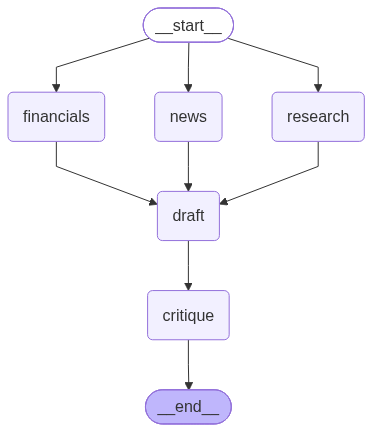

In [28]:
# Render the graph structure as a Mermaid diagram.
from IPython.display import Image, display
try:
    display(Image(scoutai.get_graph().draw_mermaid_png()))
except Exception:
    print(scoutai.get_graph().draw_mermaid())


### 6.3 — Run it end to end

The cell below streams the graph so you can watch the router dispatch to three specialists in parallel, then see draft and critique land in order. Just run it — no TODOs.


In [29]:
# 🎯 TODO: stream the graph on 'NVIDIA' (or any company) and print each node's
# output as it lands, then the final draft + critique. Streaming lets you see the
# orchestrator dispatch → each specialist finish → draft → critique in real time.

from IPython.display import HTML, display

_final_state = {}
_html_rows = []
for _step in scoutai.stream({"company": "NVIDIA"}, stream_mode="updates"):
    for _node, _update in _step.items():
        _final_state.update(_update)
        _preview = str(list(_update.values())[0])[:400].replace("<", "&lt;")
        _html_rows.append(
            f"<details style='margin:6px 0;border:1px solid #e2e6f5;border-radius:8px;padding:8px 12px;background:#fbfbff'>"
            f"<summary style='cursor:pointer;font-weight:600;color:#3b2d6b'>▶ node <code>{_node}</code> finished</summary>"
            f"<pre style='white-space:pre-wrap;font-size:12px;color:#333;margin:8px 0 0'>{_preview}…</pre>"
            f"</details>"
        )

display(HTML(
    "<div style='font-family:system-ui;max-width:900px'>"
    "<h4 style='margin:6px 0'>📡 Per-node stream</h4>"
    + "".join(_html_rows) + "</div>"
))

print("\n=== DRAFT ===\n", _final_state.get("draft", ""))
print("\n=== CRITIQUE ===\n", _final_state.get("critique", ""))



=== DRAFT ===
 # NVIDIA — One-page brief

## Risk factors
- **Cannibalization of H200 demand by hyperscalers' internal ASICs:** Per internal channel checks with three hyperscaler CTOs, demand for NVIDIA’s H200 AI chip is being eroded by customers developing their own ASICs, which could pressure future revenue growth if this trend accelerates. (Internal memo, June 2026)
- **Geopolitical and market uncertainty in China:** NVIDIA’s strategic moves in China face risks from regulatory scrutiny and competitive dynamics, especially given the recent denial of plans to launch a China-specific AI chip by year-end, which may affect market expectations and timing. (News reports, August 2026)
- **Intense competition from local Chinese AI chipmakers:** Although NVIDIA currently leads technologically, Chinese AI firms are optimizing software to compensate for trailing hardware, indicating rising competitive pressure in a critical growth market. (News reports, August 2026)

## Strategy & recent signa

In [30]:
#@title 🧠 Quick check { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r"""
<style>
.qz-q6{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:16px 18px;max-width:820px;margin:8px 0;color:#2c2350}
.qz-q6 .qz-h{font-size:14px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.qz-q6 .qz-opt{display:block;width:100%;text-align:left;background:#fff;border:1px solid #e7e4f6;border-radius:9px;padding:9px 12px;margin:5px 0;font-size:12.5px;color:#2c2350;cursor:pointer;transition:.15s;font-family:inherit}
.qz-q6 .qz-opt:hover{border-color:#8b5cf6;background:#faf7ff}
.qz-q6 .qz-opt.ok{background:#e8f7ee;border-color:#39b36a;color:#1f6b3d}
.qz-q6 .qz-opt.no{background:#fbecea;border-color:#e0796d;color:#8b2c1e}
.qz-q6 .qz-fb{margin-top:10px;padding:10px 12px;border-radius:9px;font-size:12px;color:#4b3f7a;background:#f2f0fc;border-left:3px solid #667eea;display:none;line-height:1.55}
.qz-q6 .qz-fb.show{display:block}
</style>
<div class="qz-q6">
 <div class="qz-h">🧠 What is the orchestrator actually doing in this graph?</div>
 <button class="qz-opt" data-i="0" onclick="qzPick_q6(0)">A. Doing the research itself and formatting the output.</button><button class="qz-opt" data-i="1" onclick="qzPick_q6(1)">B. Routing work to specialist sub-agents, waiting for their results, then composing.</button><button class="qz-opt" data-i="2" onclick="qzPick_q6(2)">C. Preventing the sub-agents from calling tools.</button><button class="qz-opt" data-i="3" onclick="qzPick_q6(3)">D. Reducing token cost.</button>
 <div class="qz-fb" id="qzFb_q6"></div>
</div>
<script>
function qzPick_q6(i){
  const correct = 1;
  const explain = "The orchestrator does not touch any tools directly \u2014 it dispatches to the specialists (each of which is its own ReAct agent with its own tools). The 'orchestrator + workers' pattern is the backbone of Claude Code, Cursor background agents, and OpenAI Swarm.";
  document.querySelectorAll('.qz-q6 .qz-opt').forEach((b,j)=>{
    b.classList.remove('ok','no');
    if(j===correct) b.classList.add('ok');
    else if(j===i) b.classList.add('no');
  });
  const fb = document.getElementById('qzFb_q6');
  fb.classList.add('show');
  fb.innerHTML = (i===correct ? '✅ Correct. ' : '❌ Not quite. ') + explain;
}
</script>
"""))


---
# Part 7 · MCP — publishing our tools as a protocol

Everything we did in Part 2 assumed the agent and the tools live in the **same Python process**. In real deployments they do not. Bloomberg's terminal, GitHub, your internal data warehouse — none of those are Python functions in your notebook. They are separate systems, potentially on different machines, owned by different teams.

**MCP (Model Context Protocol)** — open-sourced by Anthropic in Nov 2024 — is the standard for exposing tools *over a network* so any agent can discover and call them, without custom integration code. It is the "USB-C for AI" from the slides.

The protocol is small. Every MCP server publishes:

- **`list_tools()`** → a manifest of every tool it offers (name, description, input schema).
- **`call_tool(name, args)`** → run one and return the result.

Real MCP uses stdio or HTTP+SSE as transport. In-notebook we implement a **`MeridianMCPServer` class** with the same message shapes — one class that bundles every one of our tools (prices, news, filings, internal memos) behind a single MCP surface. Any agent can then connect to this one server and get *all* of Meridian's capabilities in one plug-in.


### 🎯 7.1 — Register our internal-memos tool with the MCP server

The `MeridianMCPServer` class below is fully wired for you — `list_tools()` and `call_tool()` are already implemented. It currently exposes two tools: live prices, and reading internal memos. recent news, and SEC filings.

**Your job:** add 2 other tools to the manifest — `get_news` — that wraps our get_news tool from part 1 and `get_filings` - that wraps our get_recent_filings from part 1; so any external MCP-speaking agent can query these tools too. This is the whole point of MCP: bundle *all* your capabilities behind one protocol so agents from anywhere can use them.

In [31]:
class MeridianMCPServer:
    """A minimal MCP-shaped server. Same message shapes as the real protocol,
    just running in-process instead of over stdio/HTTP. All the plumbing
    (list_tools + call_tool) is done for you."""

    def __init__(self):
        # Each entry: name -> {fn, schema, desc}. Add another entry to expose
        # a new capability through MCP.
        self.tools = {
            "get_price":  {"fn": lambda ticker: get_stock_snapshot.invoke({"ticker": ticker}),
                           "schema": {"ticker": "string"},
                           "desc": "Live price + 5-day change for a US ticker."},
            # 🎯 TODO 1 — add a "get_news" tool that wraps get_news.
            #   Follow the exact same shape as the entries above:
            "get_news": {"fn": lambda company, max_items: get_news.invoke({"company": company, "max_items": max_items}),
                         "schema": {"company": "string", "max_items": "integer"},
                         "desc": "Fetch recent news headlines about a company."},

            # 🎯 TODO 2 — add a "get_filings" tool that wraps get_recent_filings.
            "get_filings": {"fn": lambda ticker, max_items: get_recent_filings.invoke({"ticker": ticker, "max_items": max_items}),
                            "schema": {"ticker": "string", "max_items": "integer"},
                            "desc": "Return recent SEC filings for a US ticker."},
            "read_memos": {"fn": lambda query: search_our_research.invoke({"query": query}),
                            "schema": {"query": "string"},
                            "desc": "Search Meridian's private research memos."},
        }

    def list_tools(self):
        """MCP calls this the 'tool manifest' — the machine-readable directory of what the server offers."""
        return [{"name": name, "description": t["desc"], "input_schema": t["schema"]}
                for name, t in self.tools.items()]

    def call_tool(self, name, args):
        """Look up the tool, invoke it, wrap the result in an MCP-shaped response."""
        if name not in self.tools:
            return {"error": f"unknown tool: {name}"}
        try:
            return {"result": self.tools[name]["fn"](**args)}
        except Exception as e:
            return {"error": str(e)}

server = MeridianMCPServer()
print("📋 Tool manifest:")
import json as _json
print(_json.dumps(server.list_tools(), indent=2))

📋 Tool manifest:
[
  {
    "name": "get_price",
    "description": "Live price + 5-day change for a US ticker.",
    "input_schema": {
      "ticker": "string"
    }
  },
  {
    "name": "get_news",
    "description": "Fetch recent news headlines about a company.",
    "input_schema": {
      "company": "string",
      "max_items": "integer"
    }
  },
  {
    "name": "get_filings",
    "description": "Return recent SEC filings for a US ticker.",
    "input_schema": {
      "ticker": "string",
      "max_items": "integer"
    }
  },
  {
    "name": "read_memos",
    "description": "Search Meridian's private research memos.",
    "input_schema": {
      "query": "string"
    }
  }
]


### 🎯 7.2 — Connect an agent to the MCP server

Now the client side. `build_mcp_client_tools` reads the server's manifest and wraps each MCP tool as a regular LangChain tool. All the pydantic schema-building is done for you.

**Your job:** call `server.call_tool` once inside the closure so the LangChain tool actually invokes the MCP server when the agent uses it.


In [32]:
# The client wraps every advertised MCP tool as a regular LangChain tool.
# The LLM needs a proper arg schema so it knows which parameter names to send —
# we build one dynamically from the MCP tool's input_schema using pydantic.
from langchain_core.tools import StructuredTool
from pydantic import create_model

_TYPES = {"string": str, "integer": int, "number": float, "boolean": bool}

def build_mcp_client_tools(server):
    wrapped = []
    for t in server.list_tools():
        # Build a pydantic args model from the MCP tool's input_schema.
        fields = {k: (_TYPES.get(v, str), ...) for k, v in t["input_schema"].items()}
        ArgsSchema = create_model(f"{t['name']}_args", **fields)

        # Closure that captures the current tool name.
        def _make(name):
            def _fn(**kwargs):
                # 🎯 TODO — one line: ask the MCP server to run the tool and return its response.
                #   Hint: server.call_tool(name, kwargs)
                return server.call_tool(name, kwargs)
            return _fn

        wrapped.append(StructuredTool.from_function(
            func=_make(t["name"]),
            name=t["name"],
            description=t["description"],
            args_schema=ArgsSchema,
        ))
    return wrapped

mcp_tools = build_mcp_client_tools(server)
print(f"✅ agent sees {len(mcp_tools)} tools via MCP client")
for _t in mcp_tools:
    print(" -", _t.name, "· args:", list(_t.args_schema.model_fields.keys()))

# Run an agent that only sees the MCP-exposed tools — no direct access to our Python functions.
mcp_agent = create_agent(llm, mcp_tools)
_r = mcp_agent.invoke({"messages":[("user", "What is the current price of NVDA and one recent news item?")]})
print("\n=== agent answer ===\n", _r["messages"][-1].content)


✅ agent sees 4 tools via MCP client
 - get_price · args: ['ticker']
 - get_news · args: ['company', 'max_items']
 - get_filings · args: ['ticker', 'max_items']
 - read_memos · args: ['query']

=== agent answer ===
 The current price of NVDA (NVIDIA) is $216.85. 

One recent news item is: "Nvidia denies report it is rolling out China AI chip by year-end," reported by Reuters on August 20, 2026. You can read more about it [here](https://news.google.com/rss/articles/CBMiqAFBVV95cUxOMldWMkxfMnFZbHg4YnI0RTdoZGtfMXJIT1hTdHg4aGUyMWhvazNtdWVoLW4wMDR0cXkybXhEMHdqanBCZ0Nmb21xVVVua2lYOTQ4elZsUFlMbTBVYkpwRDBaVWs5Y0xRTUc1U3BSVng1WlpteXhqS0NhdWZ4cmthTlpFYTJJX2hrdGc0Y1VZUTJ5aXNzQWlvb19nei05RHJIYlhEZXRSYko?oc=5).


In [33]:
#@title 🔧 PROVIDED — Visualise the MCP handshake (run, don't edit) { display-mode: "form" }
from IPython.display import HTML, display
_tools = server.list_tools()
_rows = ""
for t in _tools:
    _rows += (f'<div class="mc-t"><div class="mc-n">{t["name"]}</div>'
              f'<div class="mc-d">{t["description"]}</div>'
              f'<div class="mc-s">input: {t["input_schema"]}</div></div>')
display(HTML(f"""
<style>
.mc{{font-family:system-ui;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border-radius:14px;padding:14px 16px;max-width:820px}}
.mc-flow{{display:flex;gap:8px;align-items:center;margin:8px 0 12px;font-size:12px;color:#4b3f7a}}
.mc-node{{background:#fff;border:1px solid #e7e4f6;border-radius:10px;padding:7px 12px;font-weight:800}}
.mc-t{{background:#fff;border:1px solid #e7e4f6;border-radius:10px;padding:8px 12px;margin:5px 0}}
.mc-n{{font-family:ui-monospace,Menlo;color:#8b5cf6;font-weight:800;font-size:12px}}
.mc-d{{font-size:11.5px;color:#2c2350;margin:2px 0}}
.mc-s{{font-size:10.5px;color:#8b86a6;font-family:ui-monospace,Menlo}}
</style>
<div class="mc"><b style="color:#3b2d6b">🔌 The MCP handshake</b>
<div class="mc-flow"><div class="mc-node">Agent</div>➜ list_tools() ➜<div class="mc-node">MCP Server</div>➜ manifest ➜<div class="mc-node">Agent</div></div>
<div style="font-size:11.5px;color:#6b6685;margin-bottom:6px">The manifest below is exactly what your agent receives when it connects. This same JSON shape is what Anthropic, Bloomberg, Slack, GitHub etc. publish today.</div>
{_rows}</div>"""))


In [34]:
#@title 🧠 Quick check { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r"""
<style>
.qz-q7{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:16px 18px;max-width:820px;margin:8px 0;color:#2c2350}
.qz-q7 .qz-h{font-size:14px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.qz-q7 .qz-opt{display:block;width:100%;text-align:left;background:#fff;border:1px solid #e7e4f6;border-radius:9px;padding:9px 12px;margin:5px 0;font-size:12.5px;color:#2c2350;cursor:pointer;transition:.15s;font-family:inherit}
.qz-q7 .qz-opt:hover{border-color:#8b5cf6;background:#faf7ff}
.qz-q7 .qz-opt.ok{background:#e8f7ee;border-color:#39b36a;color:#1f6b3d}
.qz-q7 .qz-opt.no{background:#fbecea;border-color:#e0796d;color:#8b2c1e}
.qz-q7 .qz-fb{margin-top:10px;padding:10px 12px;border-radius:9px;font-size:12px;color:#4b3f7a;background:#f2f0fc;border-left:3px solid #667eea;display:none;line-height:1.55}
.qz-q7 .qz-fb.show{display:block}
</style>
<div class="qz-q7">
 <div class="qz-h">🧠 Your team wants to give a new AI agent access to your internal customer database. Which of these should they build?</div>
 <button class="qz-opt" data-i="0" onclick="qzPick_q7(0)">A. A custom integration between the agent's framework and the database.</button><button class="qz-opt" data-i="1" onclick="qzPick_q7(1)">B. An MCP server wrapping the database — then any agent (yours, Cursor, Claude Desktop) can use it.</button><button class="qz-opt" data-i="2" onclick="qzPick_q7(2)">C. Rewrite the database.</button><button class="qz-opt" data-i="3" onclick="qzPick_q7(3)">D. Copy the database into the agent's prompt.</button>
 <div class="qz-fb" id="qzFb_q7"></div>
</div>
<script>
function qzPick_q7(i){
  const correct = 1;
  const explain = "Build the MCP server once. Every agent that speaks MCP \u2014 which by 2025 is all of them \u2014 can now call it without custom glue. This is exactly why MCP mattered.";
  document.querySelectorAll('.qz-q7 .qz-opt').forEach((b,j)=>{
    b.classList.remove('ok','no');
    if(j===correct) b.classList.add('ok');
    else if(j===i) b.classList.add('no');
  });
  const fb = document.getElementById('qzFb_q7');
  fb.classList.add('show');
  fb.innerHTML = (i===correct ? '✅ Correct. ' : '❌ Not quite. ') + explain;
}
</script>
"""))


---
# Part 8 · A2A — your agent hands work to another agent

MCP standardises **agent → tool**. **A2A (Agent-to-Agent protocol)**, published by Google in 2025, standardises **agent → agent** — one agent sending a task to another agent over a well-defined envelope, without either side knowing how the other is implemented.

We are going to have ScoutAI hand its brief to a `ComplianceAgent` for review. The compliance agent's job is to check the brief against a small set of Meridian's rules:
- Every numeric claim is either sourced or hedged.
- No unpublished channel-check figure is quoted without the phrase "per our channel checks".
- The mandatory disclaimer at the end is present.

An A2A envelope is a small JSON dict with five fields: **`id`**, **`from`**, **`to`**, **`task`**, **`input`** (and, in the response, **`status`** + **`result`**). Once two agents agree on that shape they can be written in different languages, by different teams, running on different servers.


In [35]:
#@title 🔧 PROVIDED — Publish two agent cards (run, don't edit) { display-mode: "form" }
from IPython.display import HTML, display
import json as _json

SCOUT_CARD = {
    "name": "ScoutAI",
    "description": "Competitive-intelligence agent for public companies.",
    "endpoint": "https://meridian.ai/agents/scoutai",  # notional
    "auth": {"type": "oauth2"},
    "skills": ["competitive_brief"],
    "input_schema": {"company": "string"},
    "output_schema": {"brief_markdown": "string"},
}

COMPLIANCE_CARD = {
    "name": "ComplianceAgent",
    "description": "Reviews text for regulatory/compliance issues (unsupported claims, missing disclaimers).",
    "endpoint": "https://meridian.ai/agents/compliance",
    "auth": {"type": "oauth2"},
    "skills": ["review_document"],
    "input_schema": {"document_markdown": "string"},
    "output_schema": {"verdict": "string", "issues": "list"},
}

_html = ""
for c,col in [(SCOUT_CARD,"#667eea"), (COMPLIANCE_CARD,"#e0a23c")]:
    _html += (f'<div class="ac-c" style="border-top:4px solid {col}">'
              f'<div class="ac-n">{c["name"]}</div>'
              f'<div class="ac-d">{c["description"]}</div>'
              f'<pre class="ac-s">{_json.dumps({k:v for k,v in c.items() if k!="description"}, indent=2)}</pre></div>')
display(HTML(f"""
<style>
.ac{{font-family:system-ui;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border-radius:14px;padding:14px 16px;max-width:900px}}
.ac-r{{display:flex;gap:12px;flex-wrap:wrap}}
.ac-c{{flex:1 1 380px;background:#fff;border:1px solid #e7e4f6;border-radius:10px;padding:10px 12px}}
.ac-n{{font-weight:800;color:#2c2350;font-size:14px}}
.ac-d{{font-size:11.5px;color:#6b6685;margin:3px 0 6px}}
.ac-s{{font-size:10.5px;color:#4b3f7a;background:#f6f4ff;border-radius:8px;padding:8px;overflow-x:auto;font-family:ui-monospace,Menlo}}
</style>
<div class="ac"><b style="color:#3b2d6b">📇 Two agent cards</b>
<div style="font-size:11.5px;color:#6b6685;margin:4px 0 8px">Each agent publishes one of these. Any other agent can discover it and know how to call it.</div>
<div class="ac-r">{_html}</div></div>"""))


### 🎯 8.1 — Implement the ComplianceAgent

The compliance agent handles one task type: `review_document`. Its job is to check a brief against Meridian's rules — unsupported numeric claims, missing disclaimers, unhedged channel-check figures — and return either `pass` (no problems) or `fail` (with a list of issues).

Most of the plumbing is written for you. You only need to fill in **one line**: the actual LLM call that produces the verdict and issue list.


In [36]:
def compliance_agent(envelope: dict) -> dict:
    """Consume an A2A envelope and return a response envelope."""
    # Unpack the request (all hand-holding done for you).
    task_type = envelope["task"]                                # should be 'review_document'
    document  = envelope["input"]["document_markdown"]

    if task_type != "review_document":
        return {"id": envelope["id"], "from": "ComplianceAgent", "to": envelope["from"],
                "status": "rejected", "result": {"error": f"unknown task {task_type}"}}

    # 🎯 TODO — one line: ask the LLM (in JSON mode) for a verdict + issues list.
    #   Use call_llm_json(...) with a prompt specifies the task, the document, and the rules.
    review = llm_json([prompt in ""] + document) # 🎯 call: llm_json([prompt in ""] + document)

    return {"id": envelope["id"],
            "from": "ComplianceAgent",
            "to": envelope["from"],
            "task": task_type,
            "status": "completed",
            "result": review}


### 🎯 8.2 — Have ScoutAI delegate to ComplianceAgent

ScoutAI produces a brief, then hands it to ComplianceAgent for review. We show the actual JSON envelopes flying between them.


In [37]:
import uuid, json as _json
from IPython.display import HTML, display

def _envelope_card(env, direction, colour):
    """Render an A2A envelope as a small HTML card (nicer than raw JSON)."""
    rows = ""
    for k, v in env.items():
        if k in ("input", "result"):
            v_str = _json.dumps(v, indent=2)
            rows += f"<div style='margin:2px 0'><b>{k}</b>:<pre style='background:#f6f4ff;padding:6px;border-radius:6px;margin:3px 0;font-size:11px'>{v_str}</pre></div>"
        else:
            rows += f"<div style='margin:2px 0'><b>{k}</b>: <code>{v}</code></div>"
    display(HTML(
        f"<div style='font-family:system-ui;max-width:820px;background:#fff;"
        f"border:1px solid #e7e4f6;border-left:5px solid {colour};border-radius:8px;"
        f"padding:10px 14px;margin:6px 0;font-size:12px;color:#2c2350'>"
        f"<div style='font-weight:700;color:{colour}'>{direction}</div>{rows}</div>"
    ))

def scout_to_compliance(company: str):
    # Step 1: ScoutAI produces the brief (reuse the graph from Part 6).
    draft = scoutai.invoke({"company": company})["draft"]

    # Step 2: build the A2A request envelope. `id`, `from`, and `input` are
    # already there — you fill in the rest.
    request = {
        "id": str(uuid.uuid4()),                                # unique task id
        "from": "ScoutAI",                                      # who's calling
        "input": {"document_markdown": draft},                  # what to review
        # 🎯 TODO — add two more keys:
        #   "to":     name of the agent you're calling  → "ComplianceAgent"
        "to": {"ComplianceAgent"},
        #   "task":   the task type this envelope carries → "review_document"
        "task": {"review_document"},
    }

    _envelope_card(request, "📤 ScoutAI → ComplianceAgent", "#667eea")

    # Step 3: hand it over. The other agent doesn't know or care how we made the brief.
    response = compliance_agent(request)

    _envelope_card(response, "📥 ComplianceAgent → ScoutAI", "#e0a23c")
    return draft, response

_draft, _resp = scout_to_compliance("Snowflake")


Read the two envelopes above. That is A2A: a task id, a from/to, a task type, an input, and a result. The two agents could have been written in different languages, by different teams, running on different servers — as long as they agree on the envelope shape, they can talk.

**Why this matters strategically:** in 2026 your firm will start acquiring agents from vendors (Salesforce, SAP, Snowflake). A2A is the protocol that lets those agents talk to yours without custom integration for every pair.


In [38]:
#@title 🧠 Quick check { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r"""
<style>
.qz-q8{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:14px;padding:16px 18px;max-width:820px;margin:8px 0;color:#2c2350}
.qz-q8 .qz-h{font-size:14px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.qz-q8 .qz-opt{display:block;width:100%;text-align:left;background:#fff;border:1px solid #e7e4f6;border-radius:9px;padding:9px 12px;margin:5px 0;font-size:12.5px;color:#2c2350;cursor:pointer;transition:.15s;font-family:inherit}
.qz-q8 .qz-opt:hover{border-color:#8b5cf6;background:#faf7ff}
.qz-q8 .qz-opt.ok{background:#e8f7ee;border-color:#39b36a;color:#1f6b3d}
.qz-q8 .qz-opt.no{background:#fbecea;border-color:#e0796d;color:#8b2c1e}
.qz-q8 .qz-fb{margin-top:10px;padding:10px 12px;border-radius:9px;font-size:12px;color:#4b3f7a;background:#f2f0fc;border-left:3px solid #667eea;display:none;line-height:1.55}
.qz-q8 .qz-fb.show{display:block}
</style>
<div class="qz-q8">
 <div class="qz-h">🧠 MCP standardises one thing, A2A standardises a different thing. What is the difference?</div>
 <button class="qz-opt" data-i="0" onclick="qzPick_q8(0)">A. MCP is for tools; A2A is for agents talking to agents.</button><button class="qz-opt" data-i="1" onclick="qzPick_q8(1)">B. MCP is Anthropic's, A2A is Google's; otherwise the same.</button><button class="qz-opt" data-i="2" onclick="qzPick_q8(2)">C. MCP is a subset of A2A.</button><button class="qz-opt" data-i="3" onclick="qzPick_q8(3)">D. A2A replaces MCP.</button>
 <div class="qz-fb" id="qzFb_q8"></div>
</div>
<script>
function qzPick_q8(i){
  const correct = 0;
  const explain = "MCP is the protocol between an agent and a tool (agent \u2194 MCP server). A2A is the protocol between two agents (agent \u2194 agent). You will use both, for different jobs.";
  document.querySelectorAll('.qz-q8 .qz-opt').forEach((b,j)=>{
    b.classList.remove('ok','no');
    if(j===correct) b.classList.add('ok');
    else if(j===i) b.classList.add('no');
  });
  const fb = document.getElementById('qzFb_q8');
  fb.classList.add('show');
  fb.innerHTML = (i===correct ? '✅ Correct. ' : '❌ Not quite. ') + explain;
}
</script>
"""))


---
## 🏁 What you built

Eight builds of the same tool. Each one closed a gap:

| Part | What we added | What it fixed |
|---|---|---|
| 1 | Plain LLM call | (baseline — showed the wall) |
| 2 | Tools + LangChain | live data, real sources |
| 3 | RAG | private context |
| 4 | Skills | consistent output |
| 5 | Memory | cross-session persistence |
| 6 | LangGraph | real control flow, parallel sub-agents |
| 7 | MCP | tools published as a protocol |
| 8 | A2A | agents talking to agents |

Every one of these terms is now something you have **implemented with your own hands** — not just heard in a slide.

The next time your dev team says "we're using LangGraph" or "we should expose this via MCP", you know exactly what they mean and, more importantly, why they picked it.
